In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.auto import tqdm
from scipy.spatial import KDTree
from astropy.coordinates import SkyCoord
import astropy.units as u

In [46]:
# Calculate blends
def magsum(magss):
    return -2.5*np.log10(np.sum(10**(-0.4*magss)))

def calc_blends(l,b,blend_rad=0.45/2/3600, maglim=19, maglim_hi=11.5, filt='UKIDSS_H'):
    dat0 = pd.read_hdf(f'outputfiles/ukirt/blend/Huston2025_l{l:.3f}_b{b:.3f}.h5')
    dat0 = dat0[~np.isnan(dat0[filt])]
    dat0.reset_index(drop=True,inplace=True)
    all_blends = np.zeros(len(dat0))
    dat_all = dat0.copy()
    dat_all.reset_index(inplace=True,names='orig_idx')
    all_l, all_b = dat_all['l'].to_numpy(), dat_all['b'].to_numpy()
    delta_l_cosb = ((all_l-360*(all_l>180))-l)*np.cos(all_b*np.pi/180)
    delta_b = all_b-b
    mags = dat_all[filt].to_numpy()
    mmin, mmax = np.floor(np.min(mags)), np.ceil(np.max(mags))
    
    blend_mags = []
    mlim = mmin
    pbar = tqdm(total=len(dat_all), position=0, leave=True)
    while len(dat_all)>0:
        # re-set arrays
        mags = dat_all[filt].to_numpy()
        all_l, all_b = dat_all['l'].to_numpy(), dat_all['b'].to_numpy()
        delta_l_cosb = ((all_l-360*(all_l>180))-l)*np.cos(all_b*np.pi/180)
        delta_b = all_b-b
        all_pts = np.transpose([all_l,all_b])
        kdt = KDTree(all_pts)

        # do the thing
        dmag = 0.5
        mlim = mlim + dmag
        bstars = np.where(mags<mlim)[0]
        all_qbp=[]
        if len(bstars)>0:
            qbp = kdt.query_ball_point(all_pts[bstars], blend_rad)
            all_qbp = np.concatenate(qbp)
            while len(np.unique(all_qbp)) != len(all_qbp):
                dmag = dmag/2
                mlim = mlim-dmag
                bstars = np.where(mags<mlim)[0]
                if len(bstars)==0:
                    all_qbp=[]
                    continue
                qbp = kdt.query_ball_point(all_pts[bstars], blend_rad)
                all_qbp = np.concatenate(qbp)
            for i,b in enumerate(bstars):
                bmag = magsum(mags[qbp[i]])
                blend_mags.append(bmag)
                all_blends[(dat_all['orig_idx'][qbp[i]])] = bmag
            dat_all.drop(index=all_qbp, inplace=True)
            dat_all.reset_index(inplace=True, drop=True)
        pbar.update(len(all_qbp))
    return sum((dat0[filt]<maglim) & (dat0[filt]>maglim_hi)), \
           sum((np.array(blend_mags)<maglim))

In [56]:
# ls = []; bs = []
# cts_in_h = []
# cts_out_h = []
# cts_in_k = []
# cts_out_k = []
# for b in np.arange(-2, 0.5, 0.1)+0.05:
#     for l in np.arange(-1.0, 1.0, 0.1)+0.05:
#         print(l,b)
#         ls.append(l); bs.append(b)
#         ct_in,ct_out = calc_blends(l,b)
#         cts_in_h.append(ct_in)
#         cts_out_h.append(ct_out)
#         ct_in,ct_out = calc_blends(l,b, maglim=18, filt='UKIDSS_K')
#         cts_in_k.append(ct_in)
#         cts_out_k.append(ct_out)

In [48]:
# rat_h = np.array(cts_out_h)/np.array(cts_in_h)
# rat_k = np.array(cts_out_k)/np.array(cts_in_k)
# rats = pd.DataFrame({'l':ls, 'b':bs, 'ratio_h':rat_h, 'ratio_k':rat_k})
# rats.to_csv('ukirt_blends.txt')
rats = pd.read_csv('ukirt_blends.txt')

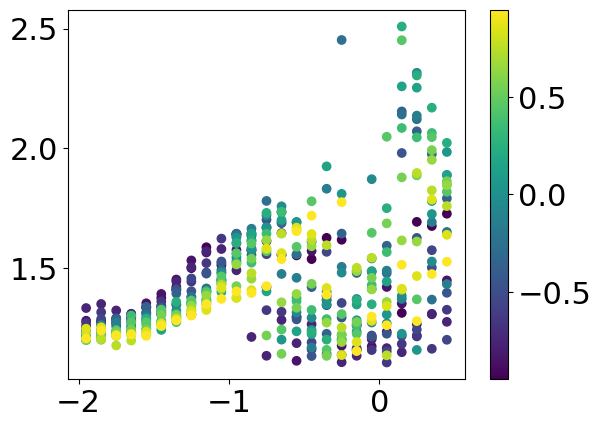

In [50]:
plt.scatter(rats['b'], rats['ratio_h'], c=rats['l'])
plt.colorbar()

In [51]:
datk = pd.read_csv('mulens_rates_ukirt_k_tElim.txt')
dath = pd.read_csv('mulens_rates_ukirt_h_tElim.txt')
dath.keys()

Index(['l', 'b', 'n_source', 'n_lens', 'sa_source', 'sa_lens', 'avg_tau',
       'avg_murel', 'avg_theta', 'eventrate_area', 'eventrate_source', 'avg_t',
       'avg_logt', 'stdev_t', 'stdev_logt', 'avg_ds', 'avg_dl', 'stdev_ds',
       'stdev_dl', 'stdev_t.1', 'frac_bulge_lens', 'frac_disk_lens',
       'frac_bulge_source', 'frac_disk_source', 'n_compact_obj',
       'frac_compact_obj', 'frac_lowmass', 'field_id', 'f_src', 'f_lens',
       'frac_nsd_lens', 'frac_nsd_source'],
      dtype='object')

In [52]:
b_bins = np.array([-2,-1.5,-1,-0.5,0,0.5])
l_bins = np.array([-1,1])

In [53]:
ukirt_obs = np.array([26.7, 31.1, 52.9, 70.1, 63.8])*1e-6
ukirt_obs_err = np.array([16, 13, 15, 7.2, 7])*1e-6

In [54]:
rate_k, rate_h = np.zeros(5), np.zeros(5)
for i in range(len(l_bins)-1):
    for j in range(len(b_bins)-1):
        subset_k = datk[(datk['l']>l_bins[i]) & (datk['l']<l_bins[i+1])
                     & (datk['b']>b_bins[j]) & (datk['b']<b_bins[j+1])].copy()
        subset_h = dath[(dath['l']>l_bins[i]) & (dath['l']<l_bins[i+1])
                     & (dath['b']>b_bins[j]) & (dath['b']<b_bins[j+1])].copy()
        
        for k in subset_h.index:
            ct_idx = np.argmin(np.sqrt((subset_k['l'][k]-rats['l'])**2 +
                                       (subset_k['b'][k]-rats['b'])**2))
            subset_h.loc[k,'ratio'] = rats['ratio_h'][ct_idx]
            subset_k.loc[k,'ratio'] = rats['ratio_k'][ct_idx]
        
        rate_k[j] = np.sum(subset_k['eventrate_source'] * subset_k['n_source']/subset_k['sa_source'])/ \
                    np.sum(subset_k['n_source']*subset_k['ratio']/subset_k['sa_source'])
        rate_h[j] = np.sum(subset_h['eventrate_source'] * subset_h['n_source']/subset_h['sa_source'])/ \
                    np.sum(subset_h['n_source']*subset_h['ratio']/subset_h['sa_source'])
        print(rate_k[j], rate_h[j], ukirt_obs[j])

1.9465659993448244e-05 2.388757606503733e-05 2.67e-05
2.251182324379662e-05 2.5579784807737085e-05 3.11e-05
2.6870065025981007e-05 2.4056216105488994e-05 5.29e-05
3.384227416875767e-05 3.597428116094375e-05 7.01e-05
3.207714233676412e-05 3.105566802811185e-05 6.379999999999999e-05


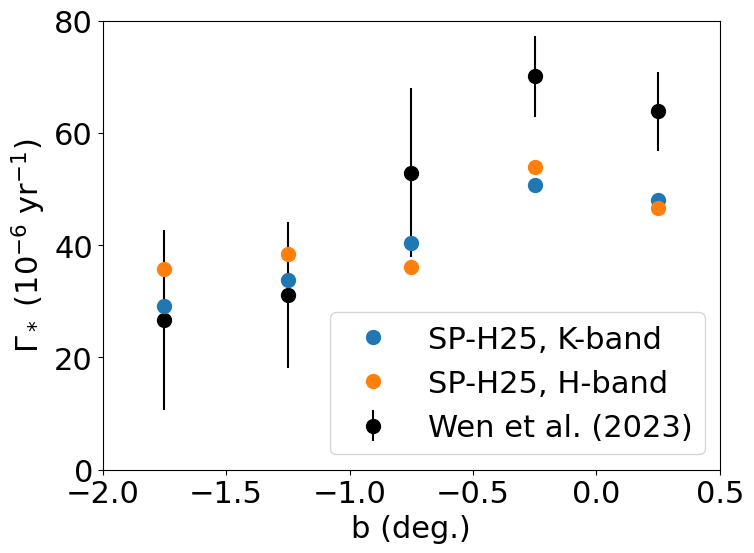

In [116]:
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(8,6))
plt.errorbar(b_bins[:-1]+np.diff(b_bins)/2, ukirt_obs*1e6, yerr=ukirt_obs_err*1e6, 
             linestyle='none', marker='o', label='Wen et al. (2023)', markersize=10,zorder=0, c='k')
#plt.errorbar([-0.75], [96], yerr=[[33],[47]], marker='o', markersize=10,zorder=1,c='gray')
plt.plot(b_bins[:-1]+np.diff(b_bins)/2, rate_k*1e6*1.5, 'o', label=r'SP-H25, K-band', markersize=10) #11.5<K$_{\rm src}$<18
plt.plot(b_bins[:-1]+np.diff(b_bins)/2, rate_h*1e6*1.5, 'o', label=r'SP-H25, H-band', markersize=10) #11.5<H$_{\rm src}$<19'
plt.legend(loc=4)
plt.xlim(-2,0.5)
plt.ylim(0,80)
plt.ylabel(r'$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)')
plt.xlabel('b (deg.)')
plt.tight_layout()
plt.savefig('figures/ukirt_rate_v2.png')
plt.savefig('figures/ukirt_rate_v2.pdf')

In [113]:
evs = pd.read_csv('data/ukirt_events.txt', sep='\s+', header=None, 
                  names=['Seq','RAdeg','DEdeg','u0','E_u0','e_u0','t0','E_t0','e_t0','tE','E_tE',
                         'e_tE','fbl','E_fbl','e_fbl'])
coords = SkyCoord(ra=evs.RAdeg.to_numpy()*u.degree, dec=evs.DEdeg.to_numpy()*u.degree, frame='icrs').transform_to('galactic')
evs.loc[:,'l'] = coords.l.degree - 360*(coords.l.degree>180)
evs.loc[:,'b'] = coords.b.degree
evs = evs[(np.abs(evs['l'])<1)].copy().reset_index(drop=True)
evs

,Seq,RAdeg,DEdeg,u0,E_u0,e_u0,t0,E_t0,e_t0,tE,E_tE,e_tE,fbl,E_fbl,e_fbl,l,b
0,UKIRT004,265.819739,-27.540654,0.114,0.009,0.008,7216.719,0.025,0.026,19.809,1.245,1.105,0.354,0.027,0.026,0.919779,1.169370
1,UKIRT006,267.704476,-28.549154,0.272,0.020,0.030,7561.446,0.106,0.100,20.440,1.662,0.943,0.887,0.078,0.114,0.919809,-0.775851
2,UKIRT007,266.010735,-27.775612,1.261,0.108,0.188,7214.190,0.152,0.145,3.352,0.382,0.221,0.767,0.167,0.233,0.808404,0.902118
3,UKIRT011,267.869168,-28.858627,0.341,0.056,0.069,7490.856,0.225,0.240,24.765,4.329,2.469,0.731,0.163,0.178,0.727639,-1.058199
4,UKIRT012,267.895224,-28.684542,0.501,0.087,0.106,7509.146,0.162,0.166,15.685,2.713,1.562,0.692,0.192,0.199,0.889017,-0.988971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,UKIRT518,266.571232,-28.775659,0.007,0.007,0.005,8694.405,0.080,0.082,42.522,0.073,0.052,0.999,0.001,0.002,0.212843,-0.040791
366,UKIRT519,267.893547,-29.238653,0.010,0.010,0.003,8593.422,0.216,0.206,216.250,92.026,102.576,0.005,0.004,0.001,0.411656,-1.270497
367,UKIRT520,265.954352,-28.327286,0.383,0.323,0.140,8617.001,0.133,0.130,6.143,2.164,1.956,0.092,0.140,0.040,0.312404,0.655438
368,UKIRT521,265.953223,-28.326865,0.144,0.159,0.069,8616.884,0.154,0.178,10.390,4.650,3.581,0.052,0.057,0.022,0.312242,0.656505


(array([83., 51., 43., 37., 32., 27., 25., 17., 14., 17., 12.,  8.,  2.,
         0.,  2.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5]),
 <BarContainer object of 15 artists>)

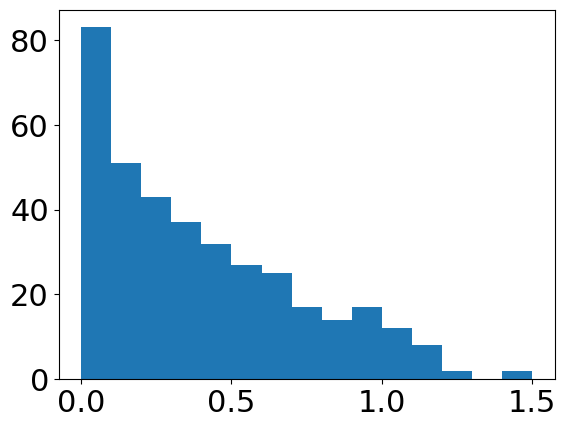

In [114]:
plt.hist(evs['u0'], bins=np.linspace(0,1.5,16))

In [115]:
ct,_ = np.histogram(evs['b'], bins=np.linspace(-2,0.5,6))
ct

array([17, 35, 74, 94, 83])

In [102]:
c = ukirt_obs/ukirt_obs_err**2

In [103]:
c

array([ 104296.875     ,  184023.66863905,  235111.11111111,
       1352237.65432099, 1302040.81632653])

In [104]:
ukirt_obs*1e6

array([26.7, 31.1, 52.9, 70.1, 63.8])

In [105]:
ct/c*1e6

array([162.99625468, 179.32475884, 293.47826087,  65.07731812,
        59.90595611])

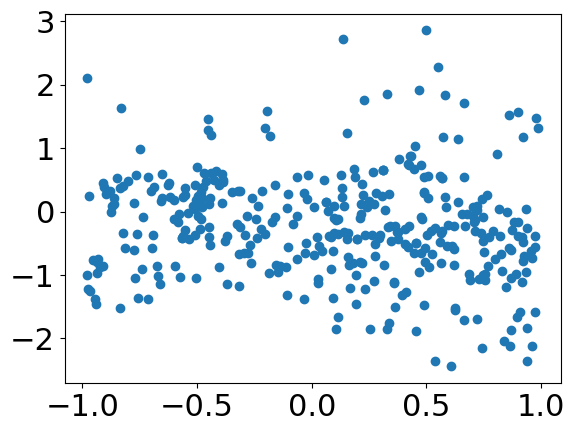

In [91]:
plt.scatter(evs['l'],evs['b'])